In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../Snowflake Notebooks Package/data/data_join.csv")
df.head(10)

,LATITUDE,LONGITUDE,DATE,TOTALAL_KALINITY,ELECTRICAL_CONDUCTANCE,DISSOLVED_REACTIVE_PHOSPHORUS,PET,NIR,GREEN,SWIR16,SWIR22,NDMI,MNDWI
0,-28.760833,17.730278,02-01-2011,128.912,555.0,10.0,174.200000,11190.0,11426.0,7687.5,7645.0,0.185538,0.195595
1,-26.861111,28.884722,03-01-2011,74.720,162.9,163.0,124.100000,17658.5,9550.0,13746.5,10574.0,0.124566,-0.180134
2,-26.450000,28.085833,03-01-2011,89.254,573.0,80.0,127.500000,15210.0,10720.0,17974.0,14201.0,-0.083293,-0.252805
3,-27.671111,27.236944,03-01-2011,82.000,203.6,101.0,129.700000,14887.0,10943.0,13522.0,11403.0,0.048048,-0.105416
4,-27.356667,27.286389,03-01-2011,56.100,145.1,151.0,129.200000,16828.5,9502.5,12665.5,9643.0,0.141147,-0.142683
5,-27.010111,26.698083,04-01-2011,82.200,289.8,192.0,98.600000,12433.5,10433.5,9579.5,8531.5,0.129651,0.042672
6,-25.127778,27.628889,04-01-2011,125.000,438.0,163.0,105.500000,7814.0,5189.5,6664.0,5222.0,0.079431,-0.124394
7,-25.206390,27.558000,04-01-2011,116.620,568.0,69.0,103.700005,14137.5,10466.5,10315.5,8536.0,0.156300,0.007266
8,-24.695140,27.409060,04-01-2011,181.831,583.0,158.0,111.800000,15543.0,10647.0,11919.5,9642.5,0.131944,-0.056389
9,-26.984722,26.632278,04-01-2011,196.000,452.0,158.0,98.200005,13683.0,10207.0,14011.5,11850.5,-0.011862,-0.157091


In [3]:
# Geospatial features

df['lat_centered'] = df['LATITUDE'] - df['LATITUDE'].mean()
df['long_centered'] = df['LONGITUDE'] - df['LONGITUDE'].mean()

df['LAT_LONG'] = df['lat_centered'] * df['long_centered']

df = df.drop(columns=['lat_centered', 'long_centered'])

In [4]:
# Temporal features (cyclical encoding)

df['DATE'] = pd.to_datetime(df['DATE'], dayfirst=True)

df['MONTH_SIN'] = np.sin(2 * np.pi * df['DATE'].dt.month)
df['MONTH_COS'] = np.cos(2 * np.pi * df['DATE'].dt.month)
df['YEAR'] = df['DATE'].dt.year

df = df.drop(columns=['DATE'])

In [5]:
# Spectral features

df['TURBIDITY_INDEX'] = df['NIR'] / (df['GREEN'] + 1e-6)
df['MOISTURE_RATIO'] = df['SWIR16'] / (df['SWIR22'] + 1e-6)

In [6]:
# Infiltrational features
df['INFIL_RATIO'] = df['MNDWI'] / (df['NDMI'] + 1e-6)

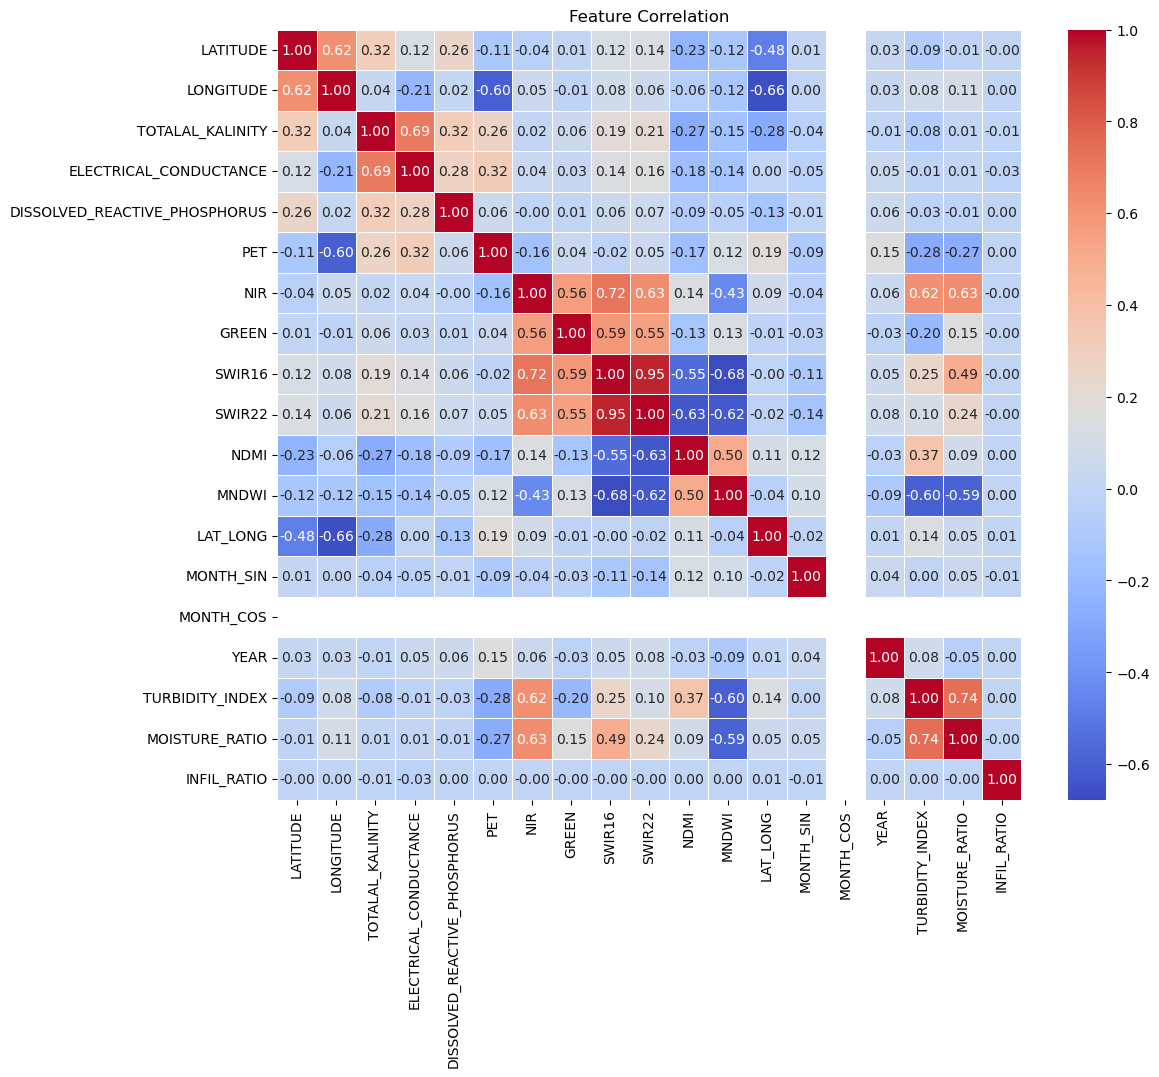

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr()

target_cols = ['TOTALAL_KALINITY', 'ELECTRICAL_CONDUCTANCE', 'DISSOLVED_REACTIVE_PHOSPHORUS']
target_corr = corr[target_cols]

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation')
plt.show()

In [8]:
df.describe()

,LATITUDE,LONGITUDE,TOTALAL_KALINITY,ELECTRICAL_CONDUCTANCE,DISSOLVED_REACTIVE_PHOSPHORUS,PET,NIR,GREEN,SWIR16,SWIR22,NDMI,MNDWI,LAT_LONG,MONTH_SIN,MONTH_COS,YEAR,TURBIDITY_INDEX,MOISTURE_RATIO,INFIL_RATIO
count,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,8234.000000,8234.000000,8234.000000,8234.000000,8234.000000,8234.000000,9319.000000,9.319000e+03,9319.0,9319.000000,8234.000000,8234.000000,8234.000000
mean,-28.474988,26.868414,119.108208,485.004146,43.525338,175.166082,14045.485426,9983.213141,13567.459315,11425.538377,0.021374,-0.144268,6.092934,-2.180052e-15,1.0,2013.104732,1.420682,1.183282,-19.197974
std,2.760282,3.535164,74.692591,341.937736,50.980194,29.469867,2953.223626,2778.780177,3348.517657,2548.193535,0.077897,0.097646,12.397394,2.433534e-15,0.0,1.384061,0.242120,0.079230,1817.705540
min,-34.405833,17.730278,4.800000,15.120000,5.000000,52.700000,3992.000000,4045.000000,3672.500000,3634.000000,-0.328293,-0.300487,-7.320965,-9.799650e-15,1.0,2011.000000,0.451995,0.896425,-164624.183007
25%,-30.160091,26.126667,55.811000,207.050000,10.000000,156.100000,12723.625000,9370.000000,11760.625000,9839.500000,-0.036869,-0.211270,-0.273069,-2.204364e-15,1.0,2012.000000,1.293171,1.139055,-2.157857
50%,-28.058889,27.409060,113.300000,402.000000,20.000000,172.500000,14183.000000,9801.000000,13704.250000,11265.250000,0.021549,-0.167901,1.301716,-1.469576e-15,1.0,2013.000000,1.418843,1.188425,-0.180618
75%,-26.861111,29.245556,170.230000,693.000000,48.000000,193.100000,15513.875000,10286.000000,15425.625000,12895.500000,0.073297,-0.104677,4.209099,-9.797174e-16,1.0,2014.000000,1.553707,1.232996,3.263877
max,-22.225556,32.325000,361.676000,1506.000000,195.000000,270.800020,65535.000000,65535.000000,65535.000000,31202.500000,0.567905,0.590974,46.124397,-2.449294e-16,1.0,2015.000000,2.681079,2.505400,4781.372307


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9319 entries, 0 to 9318
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   LATITUDE                       9319 non-null   float64
 1   LONGITUDE                      9319 non-null   float64
 2   TOTALAL_KALINITY               9319 non-null   float64
 3   ELECTRICAL_CONDUCTANCE         9319 non-null   float64
 4   DISSOLVED_REACTIVE_PHOSPHORUS  9319 non-null   float64
 5   PET                            9319 non-null   float64
 6   NIR                            8234 non-null   float64
 7   GREEN                          8234 non-null   float64
 8   SWIR16                         8234 non-null   float64
 9   SWIR22                         8234 non-null   float64
 10  NDMI                           8234 non-null   float64
 11  MNDWI                          8234 non-null   float64
 12  LAT_LONG                       9319 non-null   f

In [10]:
from sklearn.model_selection import train_test_split

features = [
    'LAT_LONG', 'MONTH_SIN', 'MONTH_COS', 'YEAR',
    'TURBIDITY_INDEX', 'MOISTURE_RATIO', 'INFIL_RATIO'
]

In [11]:
X = df.drop(columns=["TOTALAL_KALINITY", "ELECTRICAL_CONDUCTANCE", "DISSOLVED_REACTIVE_PHOSPHORUS"])
y = df[["TOTALAL_KALINITY", "ELECTRICAL_CONDUCTANCE", "DISSOLVED_REACTIVE_PHOSPHORUS"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 123
)

In [12]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

pipe = make_pipeline(
    SimpleImputer(strategy = 'median'),
    MultiOutputRegressor(GradientBoostingRegressor(n_estimators = 100, learning_rate = 0.1, max_depth = 5, min_samples_split = 2, random_state=42))
)

In [13]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'multioutputregressor__estimator__n_estimators': [100, 200, 300],
#     'multioutputregressor__estimator__learning_rate': [0.01, 0.05, 0.1],
#     'multioutputregressor__estimator__max_depth': [3, 4, 5, 6],
#     'multioutputregressor__estimator__min_samples_split': [2, 5, 10]
# }

# grid = GridSearchCV(
#     pipe, param_grid, cv = 5, scoring = 'r2', n_jobs = -1, return_train_score = True
# )

# grid.fit(X_train, y_train)
# print(f"Best parameters: {grid.best_params_}")

In [14]:
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

0.7784278464849294

In [15]:
from sklearn.model_selection import cross_val_score

r2_results =  cross_val_score(
    pipe, X_train, y_train, cv = 5, scoring = "r2"
)

r2_results

array([0.75107462, 0.75064165, 0.76429724, 0.75503939, 0.76905231])

In [16]:
y_ta = df["TOTALAL_KALINITY"]

X_train_ta, X_test_ta, y_train_ta, y_test_ta = train_test_split(
    X, y_ta, test_size = 0.2, random_state = 123
)

gb_ta = GradientBoostingRegressor(n_estimators = 100, learning_rate = 0.1, max_depth = 5, min_samples_split = 2, random_state=42)

pipe_ta = make_pipeline(SimpleImputer(strategy = 'median'), gb_ta)

pipe_ta.fit(X_train_ta, y_train_ta)
pipe_ta.score(X_test_ta, y_test_ta)

0.8326854274100686

In [17]:
r2_results_ta =  cross_val_score(
    pipe_ta, X_train_ta, y_train_ta, cv = 5, scoring = "r2"
)

r2_results_ta

array([0.7865404 , 0.7971261 , 0.82970722, 0.79673706, 0.81327542])

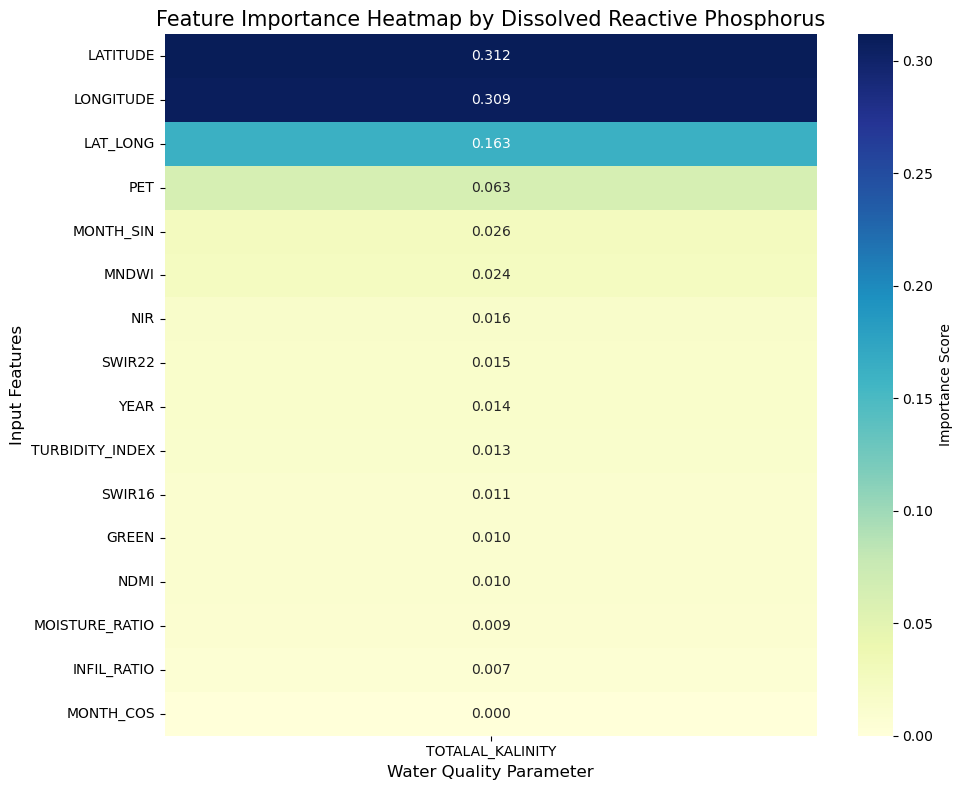

In [18]:
importances_ta = []
importances_ta.append(gb_ta.feature_importances_)

importance_ta_df = pd.DataFrame(
    np.array(importances_ta).T, 
    index=X.columns, 
    columns=["TOTALAL_KALINITY"]
)

importance_ta_df['Average'] = importance_ta_df.mean(axis=1)
importance_ta_df = importance_ta_df.sort_values(by='Average', ascending=False).drop(columns='Average')

plt.figure(figsize=(10, 8))
sns.heatmap(importance_ta_df, annot=True, cmap='YlGnBu', fmt=".3f", cbar_kws={'label': 'Importance Score'})

plt.title('Feature Importance Heatmap by Dissolved Reactive Phosphorus', fontsize=15)
plt.xlabel('Water Quality Parameter', fontsize=12)
plt.ylabel('Input Features', fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
y_ec = df["ELECTRICAL_CONDUCTANCE"]

X_train_ec, X_test_ec, y_train_ec, y_test_ec = train_test_split(
    X, y_ec, test_size = 0.2, random_state = 123
)

gb_ec = GradientBoostingRegressor(n_estimators = 100, learning_rate = 0.1, max_depth = 5, min_samples_split = 2, random_state=42)

pipe_ec = make_pipeline(SimpleImputer(strategy = 'median'), gb_ec)

pipe_ec.fit(X_train_ec, y_train_ec)
pipe_ec.score(X_test_ec, y_test_ec)

0.840586373910629

In [20]:
r2_results_ec =  cross_val_score(
    pipe_ec, X_train_ec, y_train_ec, cv = 5, scoring = "r2"
)

r2_results_ec

array([0.82179854, 0.82878401, 0.82656129, 0.82244782, 0.83631736])

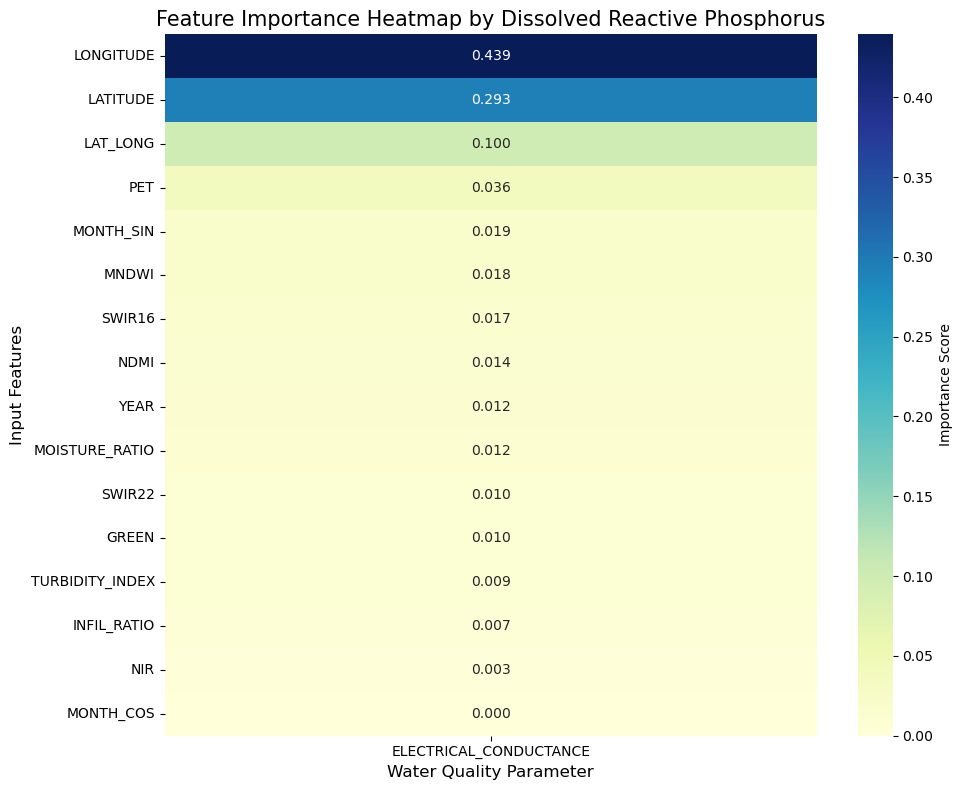

In [21]:
importances_ec = []
importances_ec.append(gb_ec.feature_importances_)

importance_ec_df = pd.DataFrame(
    np.array(importances_ec).T, 
    index=X.columns, 
    columns=["ELECTRICAL_CONDUCTANCE"]
)

importance_ec_df['Average'] = importance_ec_df.mean(axis=1)
importance_ec_df = importance_ec_df.sort_values(by='Average', ascending=False).drop(columns='Average')

plt.figure(figsize=(10, 8))
sns.heatmap(importance_ec_df, annot=True, cmap='YlGnBu', fmt=".3f", cbar_kws={'label': 'Importance Score'})

plt.title('Feature Importance Heatmap by Dissolved Reactive Phosphorus', fontsize=15)
plt.xlabel('Water Quality Parameter', fontsize=12)
plt.ylabel('Input Features', fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
y_drp = df["DISSOLVED_REACTIVE_PHOSPHORUS"]

X_train_drp, X_test_drp, y_train_drp, y_test_drp = train_test_split(
    X, y_drp, test_size = 0.2, random_state = 123
)

gb_drp = GradientBoostingRegressor(n_estimators = 300, learning_rate = 0.1, max_depth = 6, min_samples_split = 2, random_state = 42)

pipe_drp = make_pipeline(SimpleImputer(strategy = 'median'), gb_drp)

pipe_drp.fit(X_train_drp, y_train_drp)
pipe_drp.score(X_test_drp, y_test_drp)

0.7060288397927512

In [23]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'gradientboostingregressor__n_estimators': [100, 200, 300],
#     'gradientboostingregressor__learning_rate': [0.01, 0.05, 0.1],
#     'gradientboostingregressor__max_depth': [3, 4, 5, 6],
#     'gradientboostingregressor__min_samples_split': [2, 5, 10]
# }

# grid = GridSearchCV(
#     pipe_drp, param_grid, cv = 5, scoring = 'r2', n_jobs = -1, return_train_score = True
# )

# grid.fit(X_train_drp, y_train_drp)
# print(f"Best parameters: {grid.best_params_}")

In [24]:
r2_results_drp =  cross_val_score(
    pipe_drp, X_train_drp, y_train_drp, cv = 5, scoring = "r2"
)

r2_results_drp

array([0.64360188, 0.65335753, 0.66288399, 0.68820773, 0.71642788])

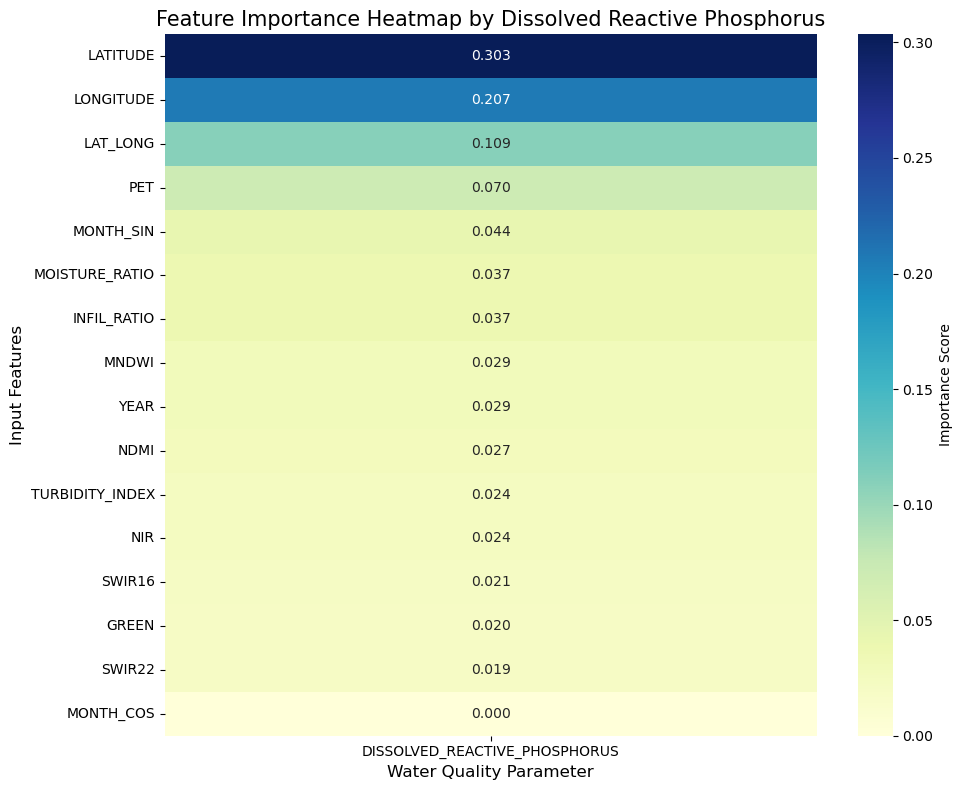

In [25]:
importances_drp = []
importances_drp.append(gb_drp.feature_importances_)

importances_drp_df = pd.DataFrame(
    np.array(importances_drp).T, 
    index=X.columns, 
    columns=["DISSOLVED_REACTIVE_PHOSPHORUS"]
)

importances_drp_df['Average'] = importances_drp_df.mean(axis=1)
importances_drp_df = importances_drp_df.sort_values(by='Average', ascending=False).drop(columns='Average')

plt.figure(figsize=(10, 8))
sns.heatmap(importances_drp_df, annot=True, cmap='YlGnBu', fmt=".3f", cbar_kws={'label': 'Importance Score'})

plt.title('Feature Importance Heatmap by Dissolved Reactive Phosphorus', fontsize=15)
plt.xlabel('Water Quality Parameter', fontsize=12)
plt.ylabel('Input Features', fontsize=12)
plt.tight_layout()
plt.show()